#GPT-Neo

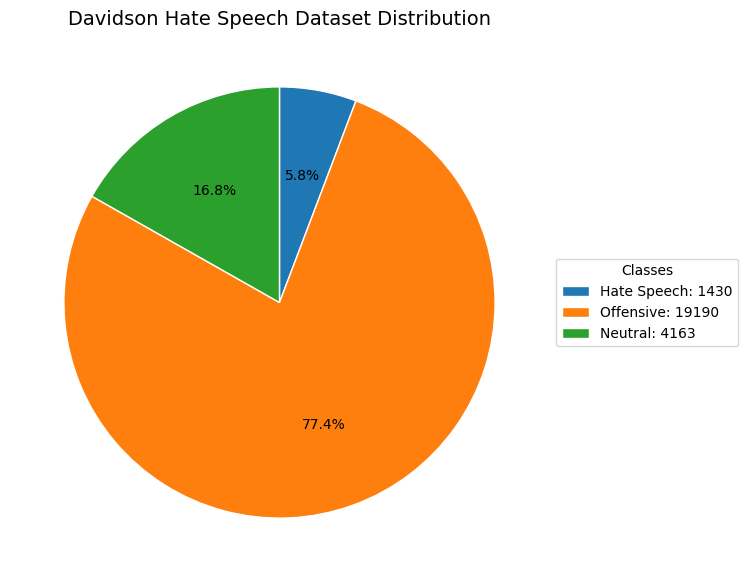

In [2]:
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter

# Load the Davidson dataset
dataset = load_dataset("tdavidson/hate_speech_offensive")
data = dataset["train"]

# Count label distribution
label_counts = Counter(data["class"])
labels = ["Hate Speech", "Offensive", "Neutral"]
sizes = [label_counts[0], label_counts[1], label_counts[2]]

# Create pie chart
plt.figure(figsize=(7,7))
wedges, texts, autotexts = plt.pie(
    sizes,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white'}
)

# Add legend with counts
legend_labels = [f"{l}: {s}" for l, s in zip(labels, sizes)]
plt.legend(wedges, legend_labels, title="Classes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title("Davidson Hate Speech Dataset Distribution", fontsize=14)
plt.show()


In [1]:
!pip install -U "transformers>=4.44.2" "datasets>=2.20.0" "accelerate>=0.25.0" "evaluate" "scikit-learn" torch torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 80.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.56.0
    Uninstalling transformers-4.56.0:
      Successfully uninstalled transformers-4.56.0


In [2]:
import transformers, datasets, torch
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Torch:", torch.__version__)

Transformers: 4.56.1
Datasets: 4.0.0
Torch: 2.8.0+cu126


### Data Processing

/tmp/ipython-input-885763216.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], palette="Blues_d")
/tmp/ipython-input-885763216.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], palette="Oranges_d")
/tmp/ipython-input-885763216.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
/tmp/ipython-input-885763216.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator

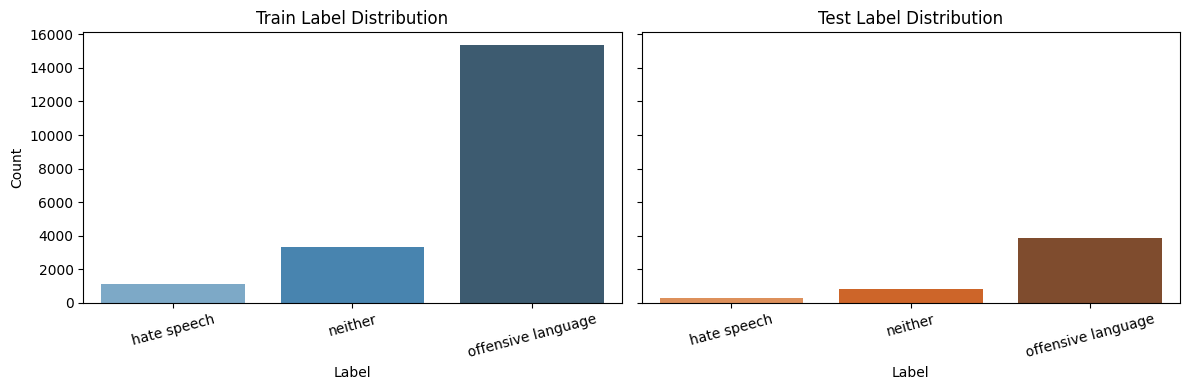

In [6]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
raw = load_dataset("tdavidson/hate_speech_offensive")["train"]
df = pd.DataFrame(raw)

label_map = {0: "hate speech", 1: "offensive language", 2: "neither"}
df["label_name"] = df["class"].map(label_map)

# 80% train, 20% test stratification
train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["class"], random_state=42
)

train_counts = train_df["label_name"].value_counts().sort_index()
test_counts = test_df["label_name"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], palette="Blues_d")
axes[0].set_title("Train Label Distribution")
axes[0].set_ylabel("Count")

sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], palette="Oranges_d")
axes[1].set_title("Test Label Distribution")

for ax in axes:
    ax.set_xlabel("Label")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()


### GPT-Neo Training

In [ ]:
import os, math, numpy as np
from dataclasses import dataclass
from typing import Dict, Any
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch
from torch import nn
from transformers import (AutoTokenizer, AutoConfig, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, Trainer, TrainingArguments, set_seed)

MODEL_ID = "EleutherAI/gpt-neo-1.3B"
DATASET_ID = "tdavidson/hate_speech_offensive"
NUM_LABELS = 3
MAX_LEN = 256
SEED = 42
set_seed(SEED)

raw = load_dataset(DATASET_ID)

split_ds = raw["train"].train_test_split(
    test_size=0.20, seed=SEED, stratify_by_column="class"
)
ds = {"train": split_ds["train"], "test": split_ds["test"]}

# --- Tokenizer ---
tok = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"

label2id = {"hate speech": 0, "offensive language": 1, "neither": 2}
id2label = {v: k for k, v in label2id.items()}

def preprocess(batch):
    enc = tok(batch["tweet"], truncation=True, max_length=MAX_LEN)
    enc["labels"] = batch["class"]  # already 0/1/2
    return enc

cols = ["input_ids", "attention_mask", "labels"]
ds_tok = {}
for split in ["train", "test"]:
    ds_tok[split] = ds[split].map(
        preprocess, batched=True, remove_columns=ds[split].column_names
    )
    ds_tok[split].set_format(type="torch", columns=cols)

labels_np = np.array(ds_tok["train"]["labels"])
class_counts = np.bincount(labels_np, minlength=NUM_LABELS)
class_weights = torch.tensor(
    (class_counts.sum() / (class_counts + 1e-9)) / NUM_LABELS, dtype=torch.float
)

config = AutoConfig.from_pretrained(
    MODEL_ID,
    num_labels=NUM_LABELS,
    pad_token_id=tok.pad_token_id,
    id2label=id2label,
    label2id=label2id,
)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, config=config)

for name, p in model.named_parameters():
    if not name.startswith("score"):
        p.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} (~{100*trainable/total:.4f}% of model)")

collator = DataCollatorWithPadding(tokenizer=tok, padding="longest")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    acc = accuracy_score(labels, preds)
    f1m = f1_score(labels, preds, average="macro")
    f1w = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1_macro": f1m, "f1_weighted": f1w}

class WeightedTrainer(Trainer):
    def __init__(self, class_weights: torch.Tensor, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./neo_davidson_clf",
    learning_rate=5e-4,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    report_to=[],
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["test"], 
    tokenizer=tok,
    data_collator=collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
)

trainer.train()

test_metrics = trainer.evaluate(ds_tok["test"])
print("Test metrics:", test_metrics)

preds = trainer.predict(ds_tok["test"]).predictions.argmax(-1)
print(
    classification_report(
        ds_tok["test"]["labels"], preds, target_names=[id2label[i] for i in range(NUM_LABELS)]
    )
)

trainer.save_model("./neo_davidson_clf/best")
tok.save_pretrained("./neo_davidson_clf/best")

def predict(texts):
    enc = tok(texts, truncation=True, max_length=MAX_LEN, return_tensors="pt", padding=True)
    with torch.no_grad():
        out = model(**{k: v.to(model.device) for k, v in enc.items()})
        pred = out.logits.argmax(-1).cpu().tolist()
    return [id2label[i] for i in pred]

print(predict([
    "I hate you and your stupid team.",
    "That movie was awful lol",
    "Have a nice day everyone!"
]))


### Evaluation

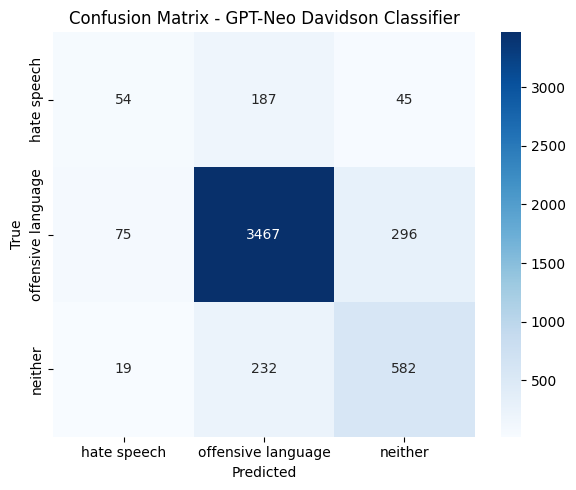

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds = trainer.predict(ds_tok["test"]).predictions.argmax(-1)
true_labels = ds_tok["test"]["labels"]

m = confusion_matrix(true_labels, preds, labels=range(NUM_LABELS))
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[id2label[i] for i in range(NUM_LABELS)],
    yticklabels=[id2label[i] for i in range(NUM_LABELS)]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - GPT-Neo Davidson Classifier")
plt.tight_layout()
plt.show()